# BMSSPy Precision Benchmark Analysis

This notebook visualizes and analyzes the precision benchmark results for BMSSPy across:
- **Real-World Road & Maritime Networks**: Geograph Marnet (11,062 nodes) & Geograph World Highways (560,282 nodes)
- **Square GridGraphs**: 100x100 (10,000 nodes), 200x200 (40,000 nodes), and 400x400 (160,000 nodes)

Across precision levels: `p8`, `p6`, `p4`, `p2`, and `p0`.

### Key Questions Investigated:
1. **Distance Accuracy**: How does rounding edge weights affect returned path lengths across networks?
2. **Error Sensitivity**: At what precision level do routing artifacts or significant distance errors emerge?
3. **Solve Runtimes**: Does decimal precision alter the performance of the BMSSP data structures or relaxation steps?
4. **Algorithmic Scaling**: How does runtime scale with node count on real-world vs synthetic grid topologies?

In [1]:
import matplotlib.pyplot as plt
from matplotlib import cm
from pamda import pamda
import math
from collections import defaultdict
import numpy as np
import os

# General plotting configurations
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Load Precision Benchmark Data

In [2]:
# Load benchmark CSV
csv_path = "./outputs/precision_benchmark_tests.csv" if os.path.exists("./outputs/precision_benchmark_tests.csv") else "./benchmarking/outputs/precision_benchmark_tests.csv"
data = pamda.read_csv(filename=csv_path)
print(f"Loaded {len(data)} test records across {len(set(r['graph_name'] for r in data))} graph configurations.")


Loaded 75 test records across 25 graph configurations.


## 2. Benchmark Summary Table Function

In [3]:
def get_summary_table(data):
    """Aggregate and display summary rows grouped by base graph and precision."""
    groups = defaultdict(list)
    for row in data:
        groups[(row["base_graph"], int(row["precision"]))].append(row)
        
    summary_rows = []
    for (base_graph, precision), rows in groups.items():
        nodes = int(rows[0]["nodes"])
        graph_type = rows[0]["graph_type"]
        avg_time = sum(float(r["solve_time_ms"]) for r in rows) / len(rows)
        
        r1 = rows[0]
        r2 = rows[1]
        c1, c2, c3 = r1["target_1_name"], r1["target_2_name"], r1["target_3_name"]
        d12 = float(r1["target_2_dist"])
        d13 = float(r1["target_3_dist"])
        d23 = float(r2["target_3_dist"])
        
        summary_rows.append({
            "graph_name": f"{base_graph}_p{precision}",
            "base_graph": base_graph,
            "graph_type": graph_type,
            "nodes": nodes,
            "precision": precision,
            "avg_time_ms": avg_time,
            "od_1_label": f"{c1} -> {c2}",
            "od_1_dist": d12,
            "od_2_label": f"{c1} -> {c3}",
            "od_2_dist": d13,
            "od_3_label": f"{c2} -> {c3}",
            "od_3_dist": d23,
        })
    return summary_rows

summary_data = get_summary_table(data)

# Print formatted table
headers = ["Graph", "Nodes", "Prec", "Avg Time (ms)", "OD Pair 1 Dist", "OD Pair 2 Dist", "OD Pair 3 Dist"]
table_rows = [
    [r["graph_name"], f"{r['nodes']:,}", str(r["precision"]), f"{r['avg_time_ms']:.2f}",
     f"{r['od_1_label']}: {r['od_1_dist']:.4f}",
     f"{r['od_2_label']}: {r['od_2_dist']:.4f}",
     f"{r['od_3_label']}: {r['od_3_dist']:.4f}"]
    for r in summary_data
]

col_widths = [len(h) for h in headers]
for row in table_rows:
    for i, val in enumerate(row):
        col_widths[i] = max(col_widths[i], len(val))

sep = "+-" + "-+-".join("-" * w for w in col_widths) + "-+"
print(sep)
print("| " + " | ".join(h.ljust(w) for h, w in zip(headers, col_widths)) + " |")
print(sep)
for row in table_rows:
    print("| " + " | ".join(v.ljust(w) for v, w in zip(row, col_widths)) + " |")
print(sep)


+----------------------+---------+------+---------------+------------------------------------+-----------------------------------+---------------------------------+
| Graph                | Nodes   | Prec | Avg Time (ms) | OD Pair 1 Dist                     | OD Pair 2 Dist                    | OD Pair 3 Dist                  |
+----------------------+---------+------+---------------+------------------------------------+-----------------------------------+---------------------------------+
| marnet_p8            | 11,062  | 8    | 240.93        | los_angeles -> new_york: 9304.8320 | los_angeles -> seattle: 2208.0920 | new_york -> seattle: 11497.4160 |
| marnet_p6            | 11,062  | 6    | 238.62        | los_angeles -> new_york: 9304.8320 | los_angeles -> seattle: 2208.0920 | new_york -> seattle: 11497.4160 |
| marnet_p4            | 11,062  | 4    | 253.38        | los_angeles -> new_york: 9304.8320 | los_angeles -> seattle: 2208.0920 | new_york -> seattle: 11497.4160 |
| marnet_p

## 3. Distance Metric Stability vs. Precision Level

Plot how calculated shortest path distances vary across precision levels (8, 6, 4, 2, 0).

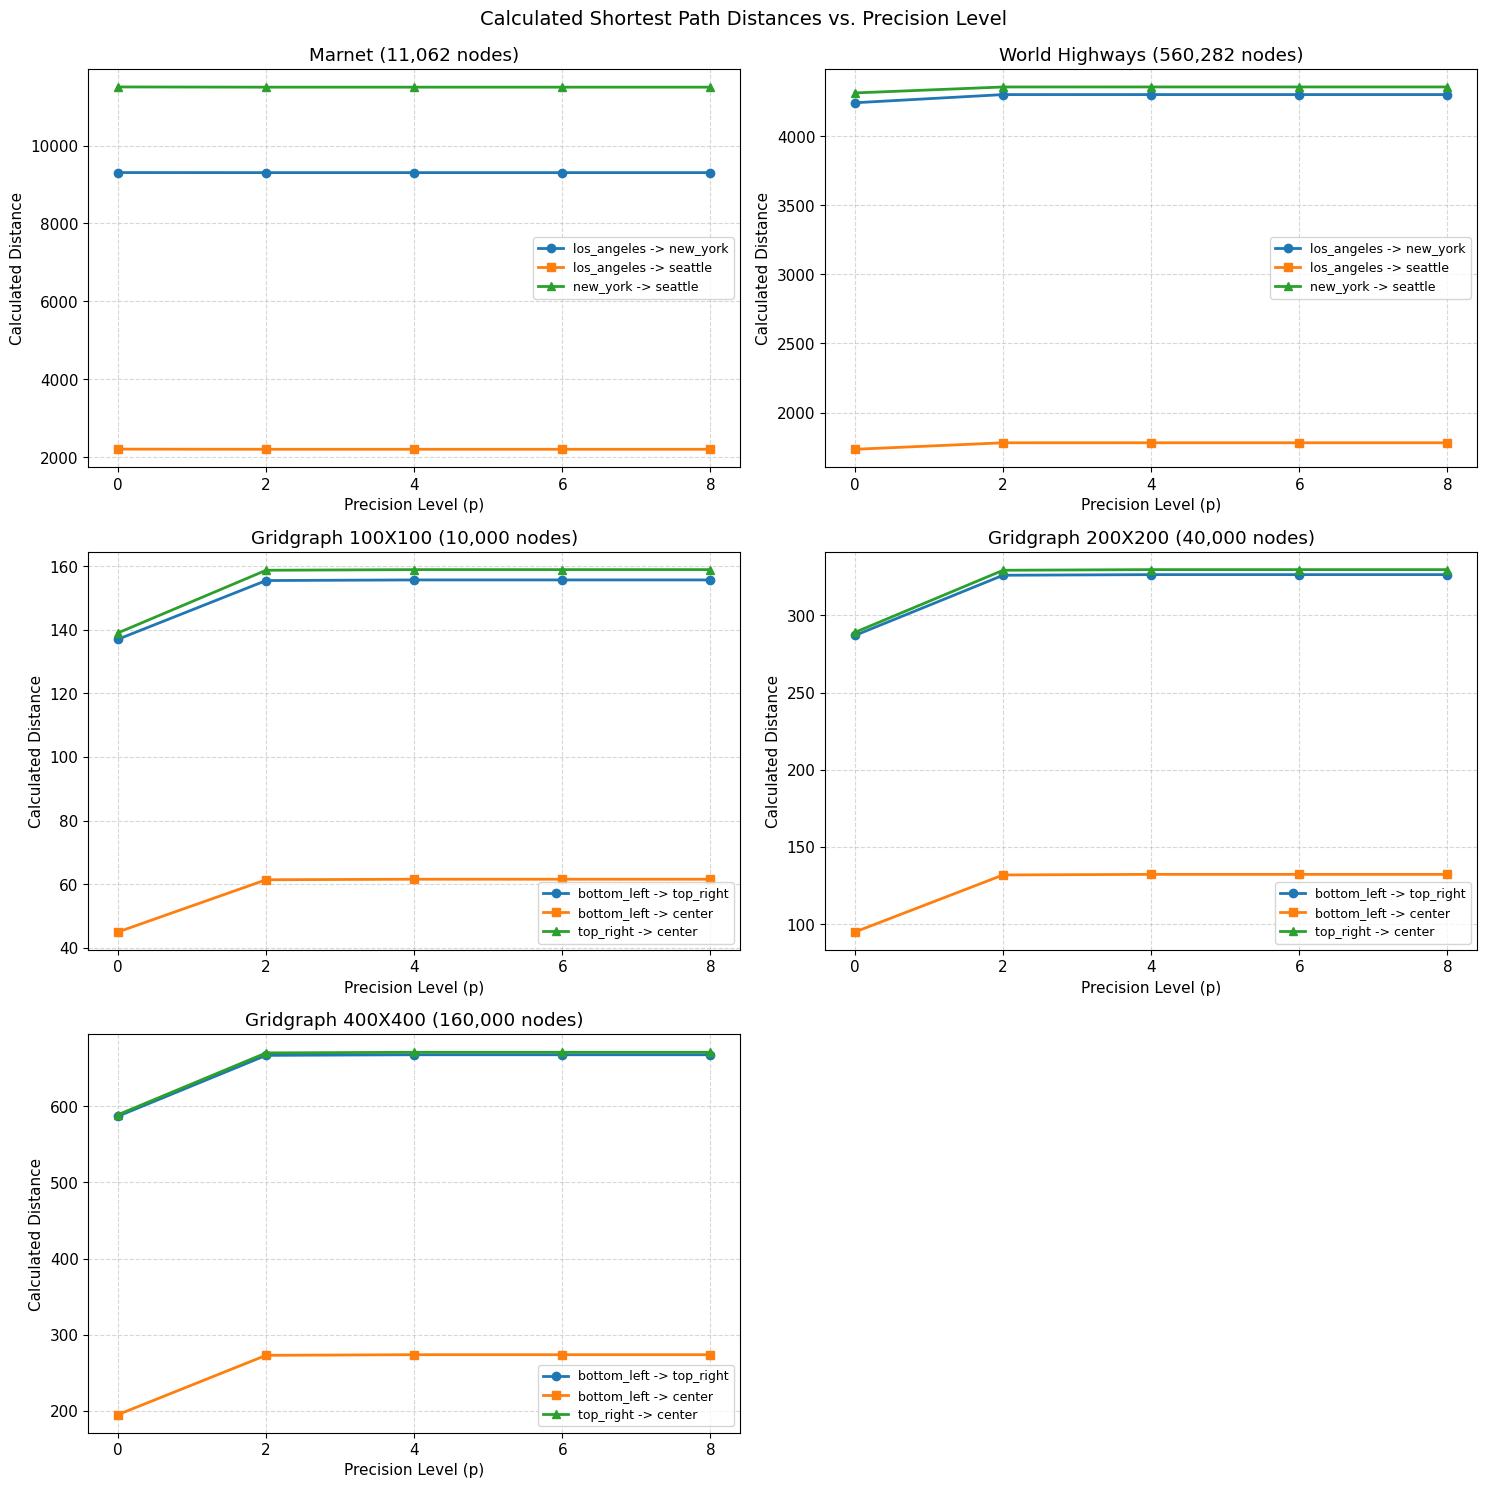

In [4]:
def plot_distance_vs_precision(summary_data, title="Calculated Shortest Path Distances vs. Precision Level"):
    base_graphs = []
    for r in summary_data:
        if r["base_graph"] not in base_graphs:
            base_graphs.append(r["base_graph"])
            
    num_graphs = len(base_graphs)
    cols = 2
    rows = (num_graphs + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    
    for idx, bg in enumerate(base_graphs):
        ax = axes[idx]
        graph_rows = sorted([r for r in summary_data if r["base_graph"] == bg], key=lambda x: x["precision"])
        
        precs = [r["precision"] for r in graph_rows]
        d1 = [r["od_1_dist"] for r in graph_rows]
        d2 = [r["od_2_dist"] for r in graph_rows]
        d3 = [r["od_3_dist"] for r in graph_rows]
        nodes = graph_rows[0]["nodes"]
        
        ax.plot(precs, d1, marker="o", linewidth=2, color=colors[0], label=graph_rows[0]["od_1_label"])
        ax.plot(precs, d2, marker="s", linewidth=2, color=colors[1], label=graph_rows[0]["od_2_label"])
        ax.plot(precs, d3, marker="^", linewidth=2, color=colors[2], label=graph_rows[0]["od_3_label"])
        
        ax.set_title(f"{bg.replace('_', ' ').title()} ({nodes:,} nodes)")
        ax.set_xlabel("Precision Level (p)")
        ax.set_ylabel("Calculated Distance")
        ax.set_xticks([0, 2, 4, 6, 8])
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(fontsize=9)
        
    for extra_idx in range(num_graphs, len(axes)):
        axes[extra_idx].set_visible(False)
        
    plt.suptitle(title, fontsize=14, y=0.99)
    plt.tight_layout()
    plt.show()

plot_distance_vs_precision(summary_data)


## 4. Percentage Error Relative to Precision 8 Baseline

Quantify percentage difference in distance relative to highest precision $p=8$:
$$\text{Error (\%)} = \frac{|\text{dist}_p - \text{dist}_{p8}|}{\text{dist}_{p8}} \times 100\%$$

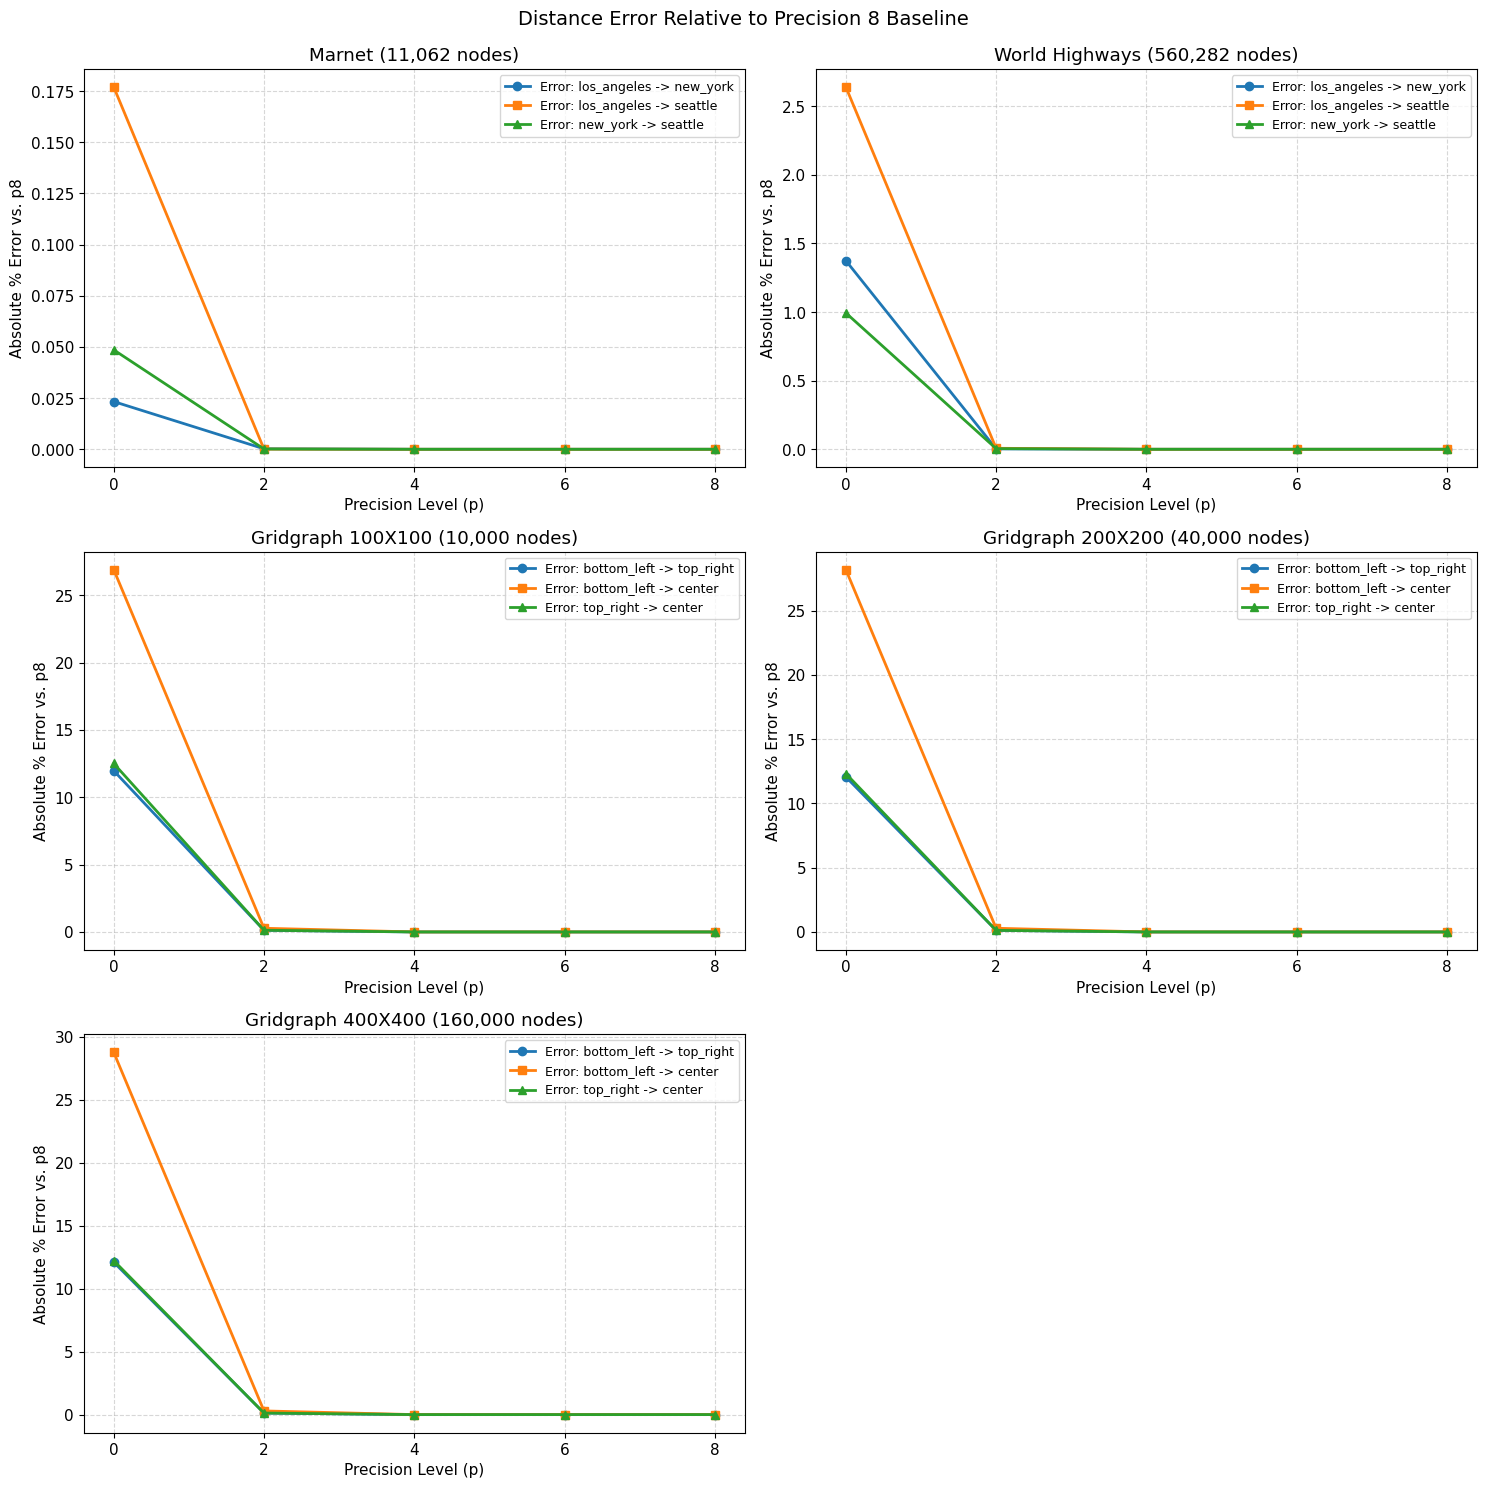

In [5]:
def plot_relative_distance_error(summary_data, title="Distance Error Relative to Precision 8 Baseline"):
    base_graphs = []
    for r in summary_data:
        if r["base_graph"] not in base_graphs:
            base_graphs.append(r["base_graph"])
            
    num_graphs = len(base_graphs)
    cols = 2
    rows = (num_graphs + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    
    for idx, bg in enumerate(base_graphs):
        ax = axes[idx]
        graph_rows = sorted([r for r in summary_data if r["base_graph"] == bg], key=lambda x: x["precision"])
        
        p8_row = next(r for r in graph_rows if r["precision"] == 8)
        precs = [r["precision"] for r in graph_rows]
        
        err1 = [100 * abs(r["od_1_dist"] - p8_row["od_1_dist"]) / p8_row["od_1_dist"] for r in graph_rows]
        err2 = [100 * abs(r["od_2_dist"] - p8_row["od_2_dist"]) / p8_row["od_2_dist"] for r in graph_rows]
        err3 = [100 * abs(r["od_3_dist"] - p8_row["od_3_dist"]) / p8_row["od_3_dist"] for r in graph_rows]
        nodes = graph_rows[0]["nodes"]
        
        ax.plot(precs, err1, marker="o", linewidth=2, color=colors[0], label=f"Error: {graph_rows[0]['od_1_label']}")
        ax.plot(precs, err2, marker="s", linewidth=2, color=colors[1], label=f"Error: {graph_rows[0]['od_2_label']}")
        ax.plot(precs, err3, marker="^", linewidth=2, color=colors[2], label=f"Error: {graph_rows[0]['od_3_label']}")
        
        ax.set_title(f"{bg.replace('_', ' ').title()} ({nodes:,} nodes)")
        ax.set_xlabel("Precision Level (p)")
        ax.set_ylabel("Absolute % Error vs. p8")
        ax.set_xticks([0, 2, 4, 6, 8])
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(fontsize=9)
        
    for extra_idx in range(num_graphs, len(axes)):
        axes[extra_idx].set_visible(False)
        
    plt.suptitle(title, fontsize=14, y=0.99)
    plt.tight_layout()
    plt.show()

plot_relative_distance_error(summary_data)


## 5. Solve Runtime vs. Precision Level

Analyze runtime behavior across precision levels for each graph network.

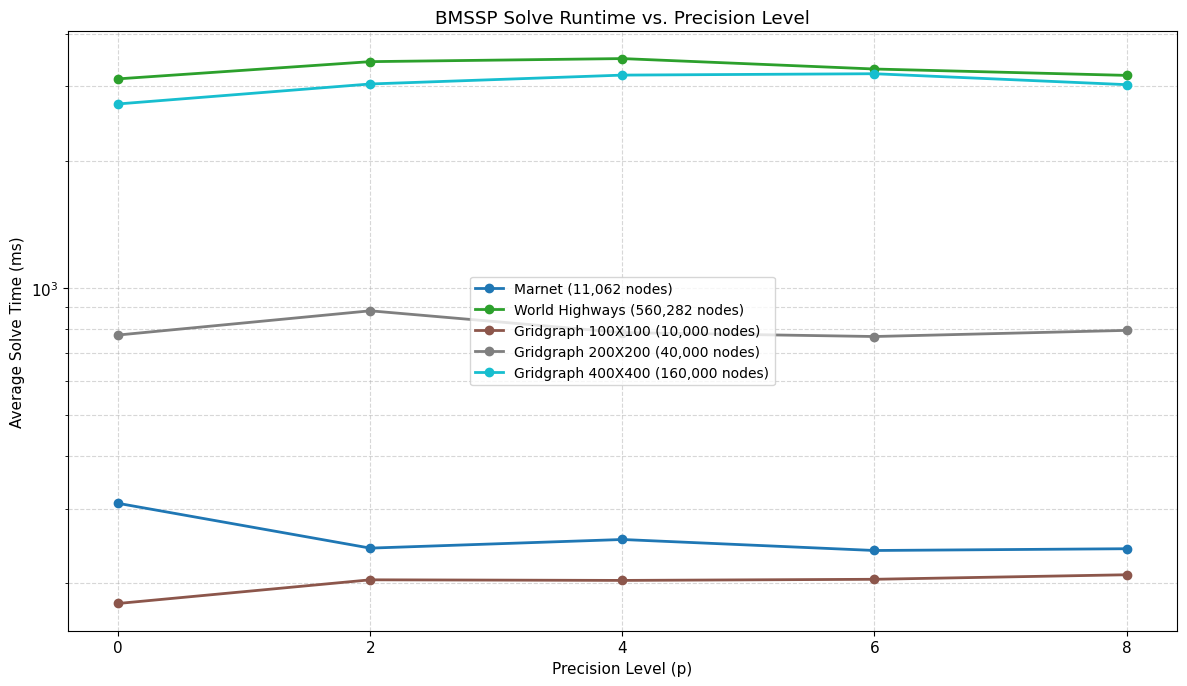

In [6]:
def plot_runtime_vs_precision(summary_data, title="BMSSP Solve Runtime vs. Precision Level"):
    base_graphs = []
    for r in summary_data:
        if r["base_graph"] not in base_graphs:
            base_graphs.append(r["base_graph"])
            
    plt.figure(figsize=(12, 7))
    palette = cm.tab10(np.linspace(0, 1, len(base_graphs)))
    
    for bg, color in zip(base_graphs, palette):
        rows = sorted([r for r in summary_data if r["base_graph"] == bg], key=lambda x: x["precision"])
        precs = [r["precision"] for r in rows]
        times = [r["avg_time_ms"] for r in rows]
        nodes = rows[0]["nodes"]
        
        plt.plot(precs, times, marker="o", linewidth=2, color=color, label=f"{bg.replace('_', ' ').title()} ({nodes:,} nodes)")
        
    plt.title(title)
    plt.xlabel("Precision Level (p)")
    plt.ylabel("Average Solve Time (ms)")
    plt.xticks([0, 2, 4, 6, 8])
    plt.yscale("log")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

plot_runtime_vs_precision(summary_data)


## 6. Problem Size Scaling: GridGraphs & Real-World Geographs

Log-log scaling curves demonstrating runtime scaling vs graph node counts.

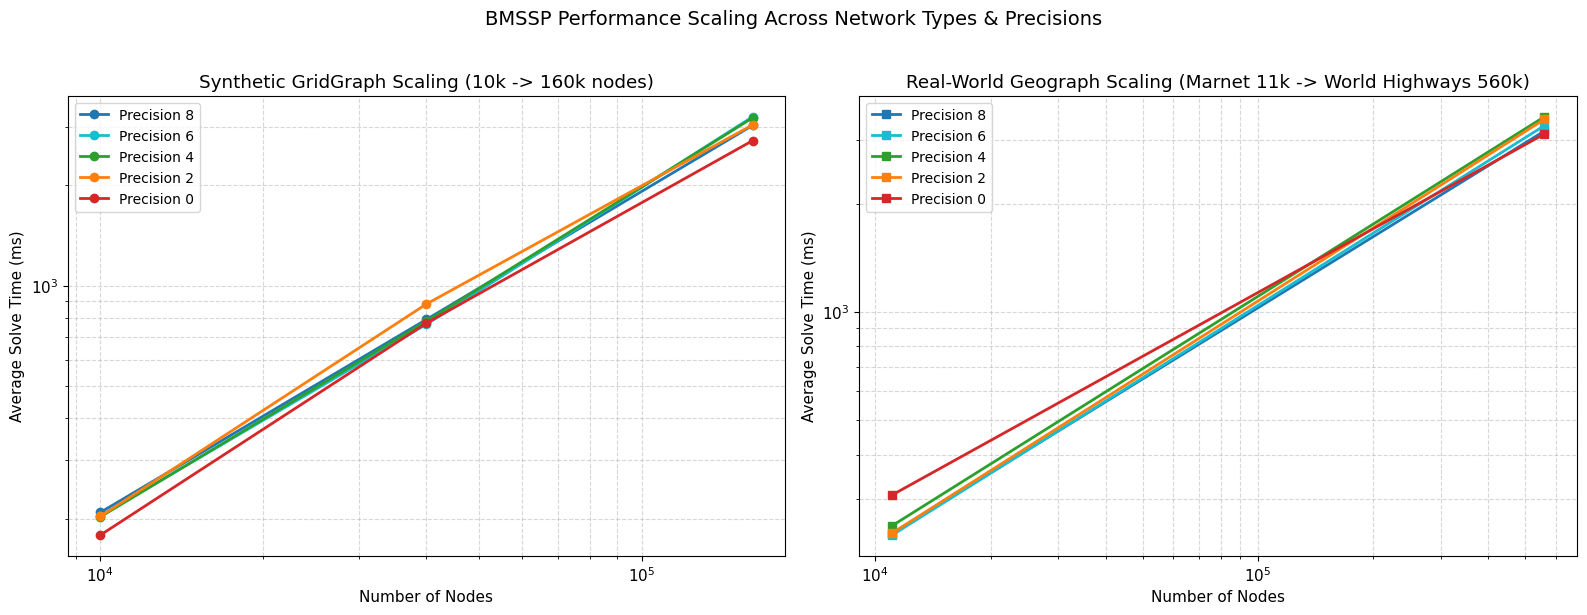

In [7]:
def plot_scaling_curves(summary_data):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    precs = [8, 6, 4, 2, 0]
    prec_colors = {8: "#1f77b4", 6: "#17becf", 4: "#2ca02c", 2: "#ff7f0e", 0: "#d62728"}
    
    # GridGraph Scaling
    grid_rows = [r for r in summary_data if r["graph_type"] == "gridgraph"]
    for p in precs:
        rows = sorted([r for r in grid_rows if r["precision"] == p], key=lambda x: x["nodes"])
        nodes = [r["nodes"] for r in rows]
        times = [r["avg_time_ms"] for r in rows]
        ax1.plot(nodes, times, marker="o", linewidth=2, color=prec_colors[p], label=f"Precision {p}")
        
    ax1.set_title("Synthetic GridGraph Scaling (10k -> 160k nodes)")
    ax1.set_xlabel("Number of Nodes")
    ax1.set_ylabel("Average Solve Time (ms)")
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.grid(True, which="both", linestyle="--", alpha=0.5)
    ax1.legend(fontsize=10)
    
    # Real-World Geograph Scaling
    geo_rows = [r for r in summary_data if r["graph_type"] == "geograph"]
    for p in precs:
        rows = sorted([r for r in geo_rows if r["precision"] == p], key=lambda x: x["nodes"])
        nodes = [r["nodes"] for r in rows]
        times = [r["avg_time_ms"] for r in rows]
        ax2.plot(nodes, times, marker="s", linewidth=2, color=prec_colors[p], label=f"Precision {p}")
        
    ax2.set_title("Real-World Geograph Scaling (Marnet 11k -> World Highways 560k)")
    ax2.set_xlabel("Number of Nodes")
    ax2.set_ylabel("Average Solve Time (ms)")
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.grid(True, which="both", linestyle="--", alpha=0.5)
    ax2.legend(fontsize=10)
    
    plt.suptitle("BMSSP Performance Scaling Across Network Types & Precisions", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_scaling_curves(summary_data)
